In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons

In [2]:
x,y = make_moons(n_samples=500, noise=0.2)

In [3]:
df = {"x1": x[:,0], "x2": x[:,1], "y": y}


In [4]:
dataset = pd.DataFrame(df)

In [5]:
dataset

,x1,x2,y
0,1.029725,-0.744714,1
1,0.486389,0.911498,0
2,-0.562171,0.859808,0
3,0.629626,0.004495,1
4,0.567762,0.726940,0
...,...,...,...
495,0.715780,-0.514077,1
496,0.530504,0.861921,0
497,0.087440,-0.104527,1
498,1.491306,-0.423436,1


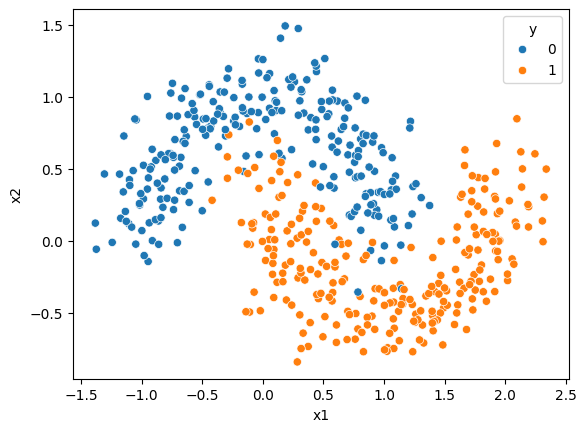

In [6]:
sns.scatterplot(x="x1", y="x2", data=dataset, hue="y")
plt.show()

In [7]:
x_a = dataset.iloc[:,:-1]
y_a = dataset["y"]

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x_a, y_a, test_size=0.2, random_state=42)

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [12]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
dt.score(x_train, y_train) * 100, dt.score(x_test, y_test) * 100

(100.0, 94.0)

In [15]:
sv = SVC()
sv.fit(x_train, y_train)
sv.score(x_train, y_train) * 100, sv.score(x_test, y_test) * 100

(96.5, 96.0)

In [17]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)
gnb.score(x_train, y_train) * 100, gnb.score(x_test, y_test) * 100

(87.0, 84.0)

Ensemble Learning

In [18]:
from sklearn.ensemble import VotingClassifier

In [19]:
li = [("dt1", DecisionTreeClassifier()), ("sv1", SVC()), ("gnb1", GaussianNB())]

In [26]:
vc = VotingClassifier(li, weights=[10, 4, 7])
vc.fit(x_train, y_train)

,estimators,"[('dt1', ...), ('sv1', ...), ...]"
,voting,'hard'
,weights,"[10, 4, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [27]:
vc.score(x_train, y_train) * 100, vc.score(x_test, y_test) * 100

(96.75, 96.0)

In [30]:
prd = {"dt": dt.predict(x_test), "svm":sv.predict(x_test), "gnb": gnb.predict(x_test), "vc": vc.predict(x_test)}

In [31]:
pd.DataFrame(prd)

,dt,svm,gnb,vc
0,0,0,0,0
1,0,0,1,0
2,0,0,0,0
3,1,1,0,1
4,0,0,0,0
...,...,...,...,...
95,0,0,0,0
96,0,0,0,0
97,0,0,1,0
98,1,1,1,1
